# MPS/MPO and DMRG simulation of a two-qubit Lindblad stationary state

This notebook is a compact demonstration of a tensor-network workflow for open quantum systems.  It includes:

1. dense two-qubit Lindblad Liouvillian construction,
2. exact stationary-state reference solution,
3. direct matrix-product-state (MPS) construction using tensor-train SVD,
4. direct matrix-product-operator (MPO) construction using operator tensor-train SVD,
5. a small single-site DMRG/ALS variational solver for the stationary state,
6. convergence plots for populations, residuals, and bond dimension.

The physical task is to solve

$$
\mathcal{L}\,|\rho_{\rm ss}\rangle\rangle=0,
\qquad
\mathrm{Tr}\rho_{\rm ss}=1,
$$

by minimizing the positive-semidefinite functional

$$
\mathcal{E}[\rho]
=\frac{\langle\langle \rho|\mathcal{L}^{\dagger}\mathcal{L}|\rho\rangle\rangle}
{\langle\langle \rho|\rho\rangle\rangle}.
$$

A true stationary state has $\mathcal{E}=0$.  The exact dense solution is used only as a benchmark; the tensor-network solver itself is implemented explicitly below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eig, eigh
from functools import reduce

np.set_printoptions(precision=10, suppress=True)

## 1. Basis and vectorization convention

The local qubit basis is

$$
|1\rangle=(1,0)^T,
\qquad
|0\rangle=(0,1)^T,
$$

where $|1\rangle$ is the excited state and $|0\rangle$ is the ground state.  The two-qubit Hilbert-space basis is

$$
|11\rangle,
|10\rangle,
|01\rangle,
|00\rangle.
$$

For the tensor-network representation of the density matrix, the Liouville vector is arranged as a four-site MPS with site order

$$
(s_1,s'_1,s_2,s'_2),
$$

where $s_i$ is a ket index and $s'_i$ is the corresponding bra index.  A population is therefore computed as

$$
P_{ab}=\rho_{ab,ab}
=\frac{\langle\langle ab,ab|\rho\rangle\rangle}
{\langle\langle I|\rho\rangle\rangle}.
$$

In [2]:
# Local basis: |1> is excited and |0> is ground.
KET_1 = np.array([1.0, 0.0], dtype=complex)
KET_0 = np.array([0.0, 1.0], dtype=complex)
LOCAL_KETS = {"1": KET_1, "0": KET_0}

STATE_LABELS = ["11", "10", "01", "00"]
POPULATION_LABELS = [
    r"$\rho_{11,11}$",
    r"$\rho_{10,10}$",
    r"$\rho_{01,01}$",
    r"$\rho_{00,00}$",
]

TENSOR_DIMS = [2, 2, 2, 2]  # (ket_1, bra_1, ket_2, bra_2)


def kron_all(arrays):
    """Kronecker product of all arrays in the input list."""
    return reduce(np.kron, arrays)


def population_projector_vector(state_label):
    """
    Return |ab><ab| as a Liouville vector in TN order
    (ket_1, bra_1, ket_2, bra_2).
    """
    if len(state_label) != 2 or any(bit not in LOCAL_KETS for bit in state_label):
        raise ValueError("state_label must be one of '11', '10', '01', '00'.")

    a, b = state_label
    return kron_all([LOCAL_KETS[a], LOCAL_KETS[a], LOCAL_KETS[b], LOCAL_KETS[b]])


def trace_vector_tn_order():
    """
    Return vec(I) in TN order (ket_1, bra_1, ket_2, bra_2).
    """
    identity = np.eye(4, dtype=complex)
    tensor_standard = identity.reshape(2, 2, 2, 2)  # (ket_1, ket_2, bra_1, bra_2)
    tensor_tn = tensor_standard.transpose(0, 2, 1, 3)
    return tensor_tn.reshape(16)


def standard_to_tn_permutation_matrix():
    """
    Build the permutation P satisfying vec_TN = P @ vec_standard.

    Standard dense vectorization order: (ket_1, ket_2, bra_1, bra_2).
    Tensor-network order:              (ket_1, bra_1, ket_2, bra_2).
    """
    P = np.zeros((16, 16), dtype=complex)
    for ket_1 in range(2):
        for ket_2 in range(2):
            for bra_1 in range(2):
                for bra_2 in range(2):
                    standard_index = ((ket_1 * 2 + ket_2) * 2 + bra_1) * 2 + bra_2
                    tn_index = ((ket_1 * 2 + bra_1) * 2 + ket_2) * 2 + bra_2
                    P[tn_index, standard_index] = 1.0
    return P


def compute_populations_from_tn_vector(rho_tn, normalize_trace=True):
    """Compute populations ordered as rho_11,11, rho_10,10, rho_01,01, rho_00,00."""
    rho_tn = np.asarray(rho_tn, dtype=complex).reshape(-1)
    trace = np.vdot(trace_vector_tn_order(), rho_tn)
    if normalize_trace:
        if abs(trace) < 1e-14:
            raise ZeroDivisionError("The trace of the candidate density matrix is numerically zero.")
        rho_tn = rho_tn / trace

    return np.array([
        np.vdot(population_projector_vector(label), rho_tn)
        for label in STATE_LABELS
    ])

## 2. Physical model: two interacting dissipative qubits

The Hamiltonian is

$$
H=h_1\sigma_z^{(1)}+h_2\sigma_z^{(2)}+J\sigma_x^{(1)}\sigma_x^{(2)}.
$$

The local decay operators are

$$
L_1=\sqrt{\Gamma_1}\,\sigma_-^{(1)},
\qquad
L_2=\sqrt{\Gamma_2}\,\sigma_-^{(2)},
$$

with

$$
\sigma_-=|0\rangle\langle 1|.
$$

Thus the dissipative channel relaxes the excited state $|1\rangle$ into the ground state $|0\rangle$.

In [3]:
SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)
SIGMA_MINUS = np.array([[0, 0], [1, 0]], dtype=complex)  # |0><1|
IDENTITY_2 = np.eye(2, dtype=complex)


def build_two_qubit_hamiltonian(local_fields, coupling_strength):
    """Construct H = h1 Z1 + h2 Z2 + J X1 X2."""
    h1, h2 = local_fields
    H = h1 * np.kron(SIGMA_Z, IDENTITY_2)
    H += h2 * np.kron(IDENTITY_2, SIGMA_Z)
    H += coupling_strength * np.kron(SIGMA_X, SIGMA_X)
    return H


def build_local_decay_operators(decay_rates):
    """Construct local collapse operators sqrt(Gamma_i) sigma_-^(i)."""
    gamma_1, gamma_2 = decay_rates
    return [
        np.sqrt(gamma_1) * np.kron(SIGMA_MINUS, IDENTITY_2),
        np.sqrt(gamma_2) * np.kron(IDENTITY_2, SIGMA_MINUS),
    ]


def build_lindblad_liouvillian(hamiltonian, collapse_operators):
    """
    Dense Lindblad Liouvillian in standard column-vectorized form.

    L = -i(H ⊗ I - I ⊗ H^T)
        + Σ_k [C_k ⊗ C_k^* - 1/2(C_k†C_k ⊗ I + I ⊗ (C_k†C_k)^T)].
    """
    H = np.asarray(hamiltonian, dtype=complex)
    dim = H.shape[0]
    identity = np.eye(dim, dtype=complex)

    liouvillian = -1j * (np.kron(H, identity) - np.kron(identity, H.T))

    for C in collapse_operators:
        C = np.asarray(C, dtype=complex)
        CdagC = C.conj().T @ C
        liouvillian += np.kron(C, C.conj())
        liouvillian -= 0.5 * (np.kron(CdagC, identity) + np.kron(identity, CdagC.T))

    return liouvillian


# Model parameters.
LOCAL_FIELDS = [5.0, 1.0]
COUPLING_STRENGTH = 2.0
DECAY_RATES = [0.2, 0.1]

HAMILTONIAN = build_two_qubit_hamiltonian(LOCAL_FIELDS, COUPLING_STRENGTH)
COLLAPSE_OPERATORS = build_local_decay_operators(DECAY_RATES)
L_STANDARD = build_lindblad_liouvillian(HAMILTONIAN, COLLAPSE_OPERATORS)

PERMUTE_STANDARD_TO_TN = standard_to_tn_permutation_matrix()
L_TN = PERMUTE_STANDARD_TO_TN @ L_STANDARD @ PERMUTE_STANDARD_TO_TN.conj().T
M_TN = L_TN.conj().T @ L_TN

print("Hamiltonian H:")
print(np.real_if_close(HAMILTONIAN))
print("\nLiouvillian shape:", L_TN.shape)
print("Hermiticity check for M=L†L:", np.linalg.norm(M_TN - M_TN.conj().T))

Hamiltonian H:
[[ 6.  0.  0.  2.]
 [ 0.  4.  2.  0.]
 [ 0.  2. -4.  0.]
 [ 2.  0.  0. -6.]]

Liouvillian shape: (16, 16)
Hermiticity check for M=L†L: 0.0


## 3. Exact dense stationary-state reference

The exact dense reference is obtained by diagonalizing $\mathcal{L}$ and selecting the right eigenvector with eigenvalue closest to zero:

$$
\mathcal{L}|\rho_{\rm ss}\rangle\rangle
=\lambda_0|\rho_{\rm ss}\rangle\rangle,
\qquad
|\lambda_0|=\min_j |\lambda_j|.
$$

The vector is normalized by $\langle\langle I|\rho_{\rm ss}\rangle\rangle=1$.  This reference is used for validation, not inside the tensor-network optimization.

In [4]:
def exact_stationary_state(liouvillian_tn):
    """Return the trace-normalized stationary state in TN vector order."""
    eigenvalues, eigenvectors = eig(liouvillian_tn)
    stationary_index = np.argmin(np.abs(eigenvalues))
    rho = eigenvectors[:, stationary_index]
    rho = rho / np.vdot(trace_vector_tn_order(), rho)
    return rho, eigenvalues[stationary_index]


rho_exact_tn, lambda_stationary = exact_stationary_state(L_TN)
exact_populations = compute_populations_from_tn_vector(rho_exact_tn)
exact_residual = np.linalg.norm(L_TN @ rho_exact_tn)

print(f"Stationary eigenvalue closest to zero: {lambda_stationary:.3e}")
print(f"Exact residual ||L rho||_2: {exact_residual:.3e}")
print("\nExact stationary populations:")
for label, value in zip(POPULATION_LABELS, exact_populations):
    print(f"  {label:>18s} = {value.real:.12f}")

Stationary eigenvalue closest to zero: 1.819e-16+1.685e-16j
Exact residual ||L rho||_2: 2.629e-15

Exact stationary populations:
      $\rho_{11,11}$ = 0.024754988118
      $\rho_{10,10}$ = 0.015093759633
      $\rho_{01,01}$ = 0.044077445087
      $\rho_{00,00}$ = 0.916073807162


## 4. Exact time-evolution sanity check

Before using tensor networks, it is useful to verify the physical behavior of the dense Lindblad model.  Starting from $|11\rangle\langle 11|$, the exact evolution is

$$
|\rho(t)\rangle\rangle=
\exp(\mathcal{L}t)|\rho(0)\rangle\rangle.
$$

The dashed lines show the exact stationary populations.

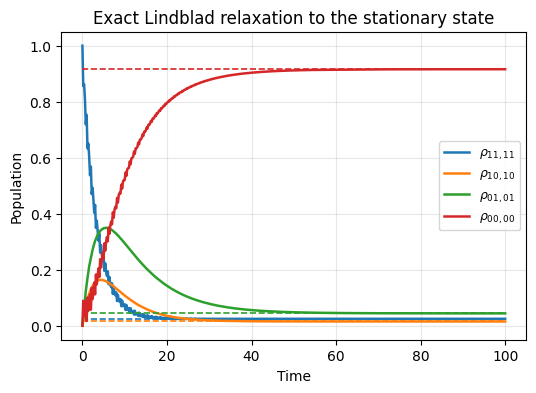

In [6]:
initial_density_tn = population_projector_vector("11")
time_grid = np.linspace(0.0, 100.0, 501)
trajectory = np.zeros((len(time_grid), 16), dtype=complex)

for i, time in enumerate(time_grid):
    trajectory[i] = expm(L_TN * time) @ initial_density_tn
    trace_error = abs(np.vdot(trace_vector_tn_order(), trajectory[i]) - 1.0)
    assert trace_error < 1e-8

fig, ax = plt.subplots(figsize=(6, 4))
for j, (state_label, pop_label) in enumerate(zip(STATE_LABELS, POPULATION_LABELS)):
    pop_vec = population_projector_vector(state_label)
    population_curve = np.real([np.vdot(pop_vec, rho_t) for rho_t in trajectory])
    line, = ax.plot(time_grid, population_curve, label=pop_label, linewidth=1.8)
    ax.hlines(
        np.real(exact_populations[j]),
        xmin=time_grid[0],
        xmax=time_grid[-1],
        colors=line.get_color(),
        linestyles="--",
        linewidth=1.2,
    )

ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.set_title("Exact Lindblad relaxation to the stationary state")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.show()

## 5. Direct MPS implementation

An MPS represents the length-$2^N$ Liouville vector as

$$
\rho_{s_1s'_1s_2s'_2}
=\sum_{\alpha_1,\alpha_2,\alpha_3}
A^{[1]}_{1,s_1,\alpha_1}
A^{[2]}_{\alpha_1,s'_1,\alpha_2}
A^{[3]}_{\alpha_2,s_2,\alpha_3}
A^{[4]}_{\alpha_3,s'_2,1}.
$$

The bond dimension $\chi$ controls the amount of correlation/compression retained.  The function `vector_to_mps` uses sequential SVDs, also known as tensor-train SVD, to convert a dense vector into an MPS with a prescribed maximum bond dimension.

In [7]:
def vector_to_mps(vector, physical_dims, max_bond=None, cutoff=1e-12):
    """
    Convert a dense vector into an open-boundary MPS using tensor-train SVD.

    Each tensor has shape (left_bond, physical_dimension, right_bond).
    """
    physical_dims = list(physical_dims)
    tensor = np.asarray(vector, dtype=complex).reshape(physical_dims)
    tensors = []
    left_bond = 1
    remainder = tensor

    for site, physical_dim in enumerate(physical_dims[:-1]):
        matrix = remainder.reshape(left_bond * physical_dim, -1)
        U, singular_values, Vh = np.linalg.svd(matrix, full_matrices=False)

        keep = int(np.sum(singular_values > cutoff))
        if max_bond is not None:
            keep = min(keep, int(max_bond))
        keep = max(1, keep)

        U = U[:, :keep]
        singular_values = singular_values[:keep]
        Vh = Vh[:keep, :]

        tensors.append(U.reshape(left_bond, physical_dim, keep))
        remainder = (singular_values[:, None] * Vh).reshape(keep, *physical_dims[site + 1:])
        left_bond = keep

    tensors.append(remainder.reshape(left_bond, physical_dims[-1], 1))
    return tensors


def mps_to_vector(mps_tensors):
    """Contract an open-boundary MPS back into a dense vector."""
    tensor = mps_tensors[0]
    for next_tensor in mps_tensors[1:]:
        tensor = np.tensordot(tensor, next_tensor, axes=([-1], [0]))
    return tensor.reshape(-1)


def normalize_mps(mps_tensors):
    """Normalize an MPS using the Euclidean norm of its dense vector."""
    vector = mps_to_vector(mps_tensors)
    norm = np.linalg.norm(vector)
    if norm < 1e-14:
        raise ZeroDivisionError("Cannot normalize an MPS with near-zero norm.")
    normalized = [tensor.copy() for tensor in mps_tensors]
    normalized[0] = normalized[0] / norm
    return normalized


def compress_mps(mps_tensors, max_bond, cutoff=1e-12):
    """Recompress an MPS by converting to a vector and applying tensor-train SVD."""
    physical_dims = [tensor.shape[1] for tensor in mps_tensors]
    return vector_to_mps(mps_to_vector(mps_tensors), physical_dims, max_bond=max_bond, cutoff=cutoff)


def mps_bond_dimensions(mps_tensors):
    """Return the internal MPS bond dimensions."""
    return [tensor.shape[2] for tensor in mps_tensors[:-1]]


# Sanity check: exact MPS conversion at full bond dimension.
rho_exact_mps = vector_to_mps(rho_exact_tn, TENSOR_DIMS, max_bond=8)
reconstruction_error = np.linalg.norm(mps_to_vector(rho_exact_mps) - rho_exact_tn)
print("MPS reconstruction error:", f"{reconstruction_error:.3e}")
print("Exact-state MPS bond dimensions:", mps_bond_dimensions(rho_exact_mps))

MPS reconstruction error: 1.280e-15
Exact-state MPS bond dimensions: [2, 4, 2]


## 6. Direct MPO implementation

An MPO represents an operator acting on the MPS Hilbert space as

$$
O_{\mathbf{s},\mathbf{t}}
=\sum_{\beta_1,\ldots,\beta_{N-1}}
W^{[1]}_{1,s_1,t_1,\beta_1}
W^{[2]}_{\beta_1,s_2,t_2,\beta_2}\cdots
W^{[N]}_{\beta_{N-1},s_N,t_N,1}.
$$

Here we construct MPOs directly from dense matrices using operator tensor-train SVD.

In [8]:
def matrix_to_mpo(matrix, input_dims, output_dims=None, max_bond=None, cutoff=1e-12):
    """
    Convert a dense matrix into an open-boundary MPO by operator TT-SVD.

    Each MPO tensor has shape (left_bond, output_dim, input_dim, right_bond).
    """
    input_dims = list(input_dims)
    if output_dims is None:
        output_dims = input_dims
    output_dims = list(output_dims)
    num_sites = len(input_dims)

    operator_tensor = np.asarray(matrix, dtype=complex).reshape(*output_dims, *input_dims)

    # Reorder from all-output/all-input axes into paired site axes:
    # (out_1,in_1,out_2,in_2,...).
    paired_axis_order = []
    for site in range(num_sites):
        paired_axis_order.extend([site, num_sites + site])
    operator_tensor = operator_tensor.transpose(paired_axis_order)

    local_operator_dims = [output_dims[i] * input_dims[i] for i in range(num_sites)]
    remainder = operator_tensor.reshape(local_operator_dims)

    tensors = []
    left_bond = 1
    for site, local_dim in enumerate(local_operator_dims[:-1]):
        matrix_view = remainder.reshape(left_bond * local_dim, -1)
        U, singular_values, Vh = np.linalg.svd(matrix_view, full_matrices=False)

        keep = int(np.sum(singular_values > cutoff))
        if max_bond is not None:
            keep = min(keep, int(max_bond))
        keep = max(1, keep)

        U = U[:, :keep]
        singular_values = singular_values[:keep]
        Vh = Vh[:keep, :]

        tensors.append(U.reshape(left_bond, output_dims[site], input_dims[site], keep))
        remainder = (singular_values[:, None] * Vh).reshape(keep, *local_operator_dims[site + 1:])
        left_bond = keep

    tensors.append(remainder.reshape(left_bond, output_dims[-1], input_dims[-1], 1))
    return tensors


def mpo_to_matrix(mpo_tensors):
    """Contract an open-boundary MPO back into a dense matrix."""
    tensor = mpo_tensors[0]
    for next_tensor in mpo_tensors[1:]:
        tensor = np.tensordot(tensor, next_tensor, axes=([-1], [0]))

    tensor = np.squeeze(tensor, axis=(0, -1))
    num_sites = len(mpo_tensors)

    # Current axes are (out_1,in_1,out_2,in_2,...). Reorder to all outputs then all inputs.
    output_axes = list(range(0, 2 * num_sites, 2))
    input_axes = list(range(1, 2 * num_sites, 2))
    tensor = tensor.transpose(output_axes + input_axes)

    output_dims = [mpo.shape[1] for mpo in mpo_tensors]
    input_dims = [mpo.shape[2] for mpo in mpo_tensors]
    return tensor.reshape(np.prod(output_dims), np.prod(input_dims))


def mpo_bond_dimensions(mpo_tensors):
    """Return the internal MPO bond dimensions."""
    return [tensor.shape[3] for tensor in mpo_tensors[:-1]]


L_MPO = matrix_to_mpo(L_TN, TENSOR_DIMS, cutoff=1e-12)
M_MPO = matrix_to_mpo(M_TN, TENSOR_DIMS, cutoff=1e-12)

L_mpo_error = np.linalg.norm(mpo_to_matrix(L_MPO) - L_TN)
M_mpo_error = np.linalg.norm(mpo_to_matrix(M_MPO) - M_TN)

print("L MPO bond dimensions:", mpo_bond_dimensions(L_MPO))
print("M=L†L MPO bond dimensions:", mpo_bond_dimensions(M_MPO))
print("L MPO reconstruction error:", f"{L_mpo_error:.3e}")
print("M MPO reconstruction error:", f"{M_mpo_error:.3e}")

L MPO bond dimensions: [4, 4, 4]
M=L†L MPO bond dimensions: [4, 9, 4]
L MPO reconstruction error: 2.452e-14
M MPO reconstruction error: 4.350e-13


## 7. Direct single-site DMRG/ALS stationary-state solver

The DMRG objective is the Rayleigh quotient

$$
E(A^{[k]})=
\frac{\langle\rho(A^{[k]})|M|\rho(A^{[k]})\rangle}
{\langle\rho(A^{[k]})|\rho(A^{[k]})\rangle},
\qquad
M=\mathcal{L}^{\dagger}\mathcal{L}.
$$

During a single-site update, all tensors except $A^{[k]}$ are fixed.  The full vector is linear in the active tensor entries:

$$
|\rho\rangle=B_k x_k.
$$

The local variational problem becomes the generalized eigenvalue problem

$$
(B_k^{\dagger} M B_k)x_k
=E_k(B_k^{\dagger}B_k)x_k.
$$

The lowest-eigenvalue eigenvector is reshaped back into the active MPS tensor.

In [9]:
def build_single_site_basis(mps_tensors, active_site):
    """
    Build the dense basis B_k mapping active tensor entries to the full MPS vector.

    This explicit construction is suitable for the present four-site pedagogical model.
    """
    active_shape = mps_tensors[active_site].shape
    num_parameters = int(np.prod(active_shape))
    full_dimension = int(np.prod([tensor.shape[1] for tensor in mps_tensors]))

    basis = np.zeros((full_dimension, num_parameters), dtype=complex)
    for column in range(num_parameters):
        trial_tensors = [tensor.copy() for tensor in mps_tensors]
        active_tensor = np.zeros(active_shape, dtype=complex)
        active_tensor.reshape(-1)[column] = 1.0
        trial_tensors[active_site] = active_tensor
        basis[:, column] = mps_to_vector(trial_tensors)

    return basis


def update_one_mps_tensor(mps_tensors, active_site, objective_matrix, overlap_regularization=1e-12):
    """Solve the local DMRG generalized eigenproblem for one active tensor."""
    basis = build_single_site_basis(mps_tensors, active_site)
    local_hamiltonian = basis.conj().T @ objective_matrix @ basis
    local_overlap = basis.conj().T @ basis

    regularized_overlap = local_overlap + overlap_regularization * np.eye(local_overlap.shape[0])
    eigenvalues, eigenvectors = eigh(local_hamiltonian, regularized_overlap)

    best_index = np.argmin(eigenvalues.real)
    optimized_tensor = eigenvectors[:, best_index].reshape(mps_tensors[active_site].shape)

    updated_tensors = [tensor.copy() for tensor in mps_tensors]
    updated_tensors[active_site] = optimized_tensor
    return normalize_mps(updated_tensors), eigenvalues[best_index].real


def initialize_noisy_product_mps(product_vector, max_bond, seed=1234, noise_strength=1e-2):
    """
    Build a deterministic noisy product initial MPS.

    A tiny random component avoids zero-environment traps that can occur with a perfectly
    rank-one product initial state in single-site updates.
    """
    rng = np.random.default_rng(seed)
    noise = noise_strength * (rng.normal(size=product_vector.size) + 1j * rng.normal(size=product_vector.size))
    initial_vector = np.asarray(product_vector, dtype=complex) + noise
    return normalize_mps(vector_to_mps(initial_vector, TENSOR_DIMS, max_bond=max_bond))


def run_single_site_dmrg(objective_matrix, initial_vector, max_bond, num_sweeps=20, cutoff=1e-12, seed=1234):
    """
    Minimize <rho|M|rho>/<rho|rho> using explicit single-site DMRG/ALS sweeps.
    """
    mps = initialize_noisy_product_mps(initial_vector, max_bond=max_bond, seed=seed)
    energy_history = []
    residual_history = []

    sweep_order = list(range(len(TENSOR_DIMS))) + list(range(len(TENSOR_DIMS) - 2, -1, -1))

    for _ in range(num_sweeps):
        for active_site in sweep_order:
            mps, _ = update_one_mps_tensor(mps, active_site, objective_matrix)
            mps = compress_mps(mps, max_bond=max_bond, cutoff=cutoff)

        vector = mps_to_vector(mps)
        norm = np.vdot(vector, vector)
        energy = np.vdot(vector, objective_matrix @ vector) / norm
        residual = np.linalg.norm(L_TN @ vector) / np.linalg.norm(vector)
        energy_history.append(energy.real)
        residual_history.append(residual.real)

    return {
        "mps": mps,
        "state_vector": mps_to_vector(mps),
        "energy_history": np.array(energy_history),
        "residual_history": np.array(residual_history),
        "bond_dimensions": mps_bond_dimensions(mps),
    }

## 8. Bond-dimension scan

The scan below tests how the stationary-state approximation improves with increasing MPS bond dimension $\chi$.  For this four-site Liouville-space example, $\chi=4$ is already sufficient to reproduce the exact dense stationary state to near machine precision.

In [10]:
BOND_DIMENSIONS = [1, 2, 3, 4, 5, 6]
NUM_SWEEPS = 20

population_scan = np.zeros((len(BOND_DIMENSIONS), len(STATE_LABELS)), dtype=float)
final_residuals = np.zeros(len(BOND_DIMENSIONS), dtype=float)
final_energies = np.zeros(len(BOND_DIMENSIONS), dtype=float)
dmrg_results = []

for row, bond_dimension in enumerate(BOND_DIMENSIONS):
    print(f"\nRunning direct DMRG with max bond dimension chi = {bond_dimension}")
    result = run_single_site_dmrg(
        objective_matrix=M_TN,
        initial_vector=initial_density_tn,
        max_bond=bond_dimension,
        num_sweeps=NUM_SWEEPS,
        cutoff=1e-12,
        seed=2026 + bond_dimension,
    )

    dmrg_results.append(result)
    normalized_vector = result["state_vector"] / np.vdot(trace_vector_tn_order(), result["state_vector"])
    populations = compute_populations_from_tn_vector(normalized_vector)

    population_scan[row, :] = np.real_if_close(populations).real
    final_residuals[row] = result["residual_history"][-1]
    final_energies[row] = result["energy_history"][-1]

    print("  internal MPS bonds:", result["bond_dimensions"])
    print(f"  final residual ||L rho||/||rho|| = {final_residuals[row]:.3e}")
    for label, population in zip(POPULATION_LABELS, population_scan[row]):
        print(f"  {label:>18s} = {population:.12f}")


Running direct DMRG with max bond dimension chi = 1
  internal MPS bonds: [1, 1, 1]
  final residual ||L rho||/||rho|| = 1.321e+00
      $\rho_{11,11}$ = 0.587119208999
      $\rho_{10,10}$ = 0.376046198081
      $\rho_{01,01}$ = 0.022453357336
      $\rho_{00,00}$ = 0.014381235584

Running direct DMRG with max bond dimension chi = 2
  internal MPS bonds: [2, 2, 2]
  final residual ||L rho||/||rho|| = 2.208e-01
      $\rho_{11,11}$ = 0.278328060426
      $\rho_{10,10}$ = 0.230783184079
      $\rho_{01,01}$ = 0.274631001366
      $\rho_{00,00}$ = 0.216257754129

Running direct DMRG with max bond dimension chi = 3
  internal MPS bonds: [2, 3, 2]
  final residual ||L rho||/||rho|| = 8.913e-03
      $\rho_{11,11}$ = 0.000365233099
      $\rho_{10,10}$ = 0.014042191757
      $\rho_{01,01}$ = 0.024985105534
      $\rho_{00,00}$ = 0.960607469610

Running direct DMRG with max bond dimension chi = 4
  internal MPS bonds: [2, 4, 2]
  final residual ||L rho||/||rho|| = 7.946e-14
      $\rho_{11,

## 9. Population convergence plot

Solid curves show the direct-MPS/DMRG results.  Dashed horizontal lines show the dense exact stationary populations.

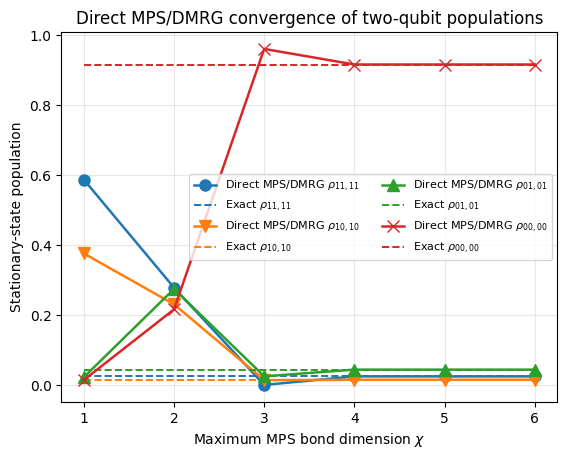

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
markers = ["o", "v", "^", "x"]

for column, (label, marker) in enumerate(zip(POPULATION_LABELS, markers)):
    line, = ax.plot(
        BOND_DIMENSIONS,
        population_scan[:, column],
        marker=marker,
        markersize=8,
        linewidth=1.8,
        label=f"Direct MPS/DMRG {label}",
    )
    ax.hlines(
        y=np.real(exact_populations[column]),
        xmin=min(BOND_DIMENSIONS),
        xmax=max(BOND_DIMENSIONS),
        colors=line.get_color(),
        linestyles="--",
        linewidth=1.4,
        label=f"Exact {label}",
    )

ax.set_xlabel("Maximum MPS bond dimension $\\chi$")
ax.set_ylabel("Stationary-state population")
ax.set_title("Direct MPS/DMRG convergence of two-qubit populations")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=2, fontsize=8)
plt.show()

## 10. Residual and objective convergence

The residual

$$
\frac{\|\mathcal{L}\rho\|_2}{\|\rho\|_2}
$$

is the most direct diagnostic of whether the tensor-network state is stationary.  The objective value is

$$
\frac{\langle\rho|\mathcal{L}^{\dagger}\mathcal{L}|\rho\rangle}
{\langle\rho|\rho\rangle}
=\frac{\|\mathcal{L}\rho\|_2^2}{\|\rho\|_2^2}.
$$

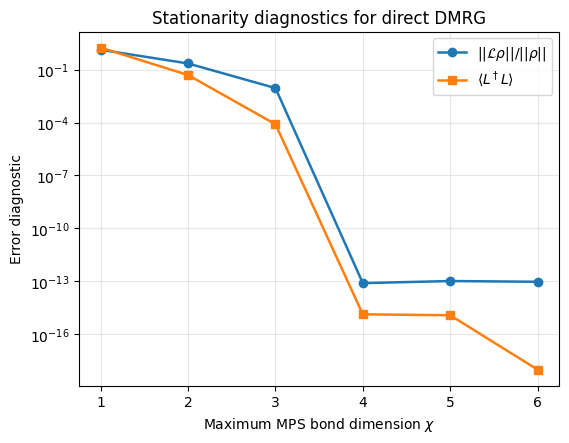

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.semilogy(BOND_DIMENSIONS, final_residuals, marker="o", linewidth=1.8, label=r"$||\mathcal{L}\rho||/||\rho||$")
ax.semilogy(BOND_DIMENSIONS, np.maximum(final_energies, 1e-18), marker="s", linewidth=1.8, label=r"$\langle L^\dagger L\rangle$")
ax.set_xlabel("Maximum MPS bond dimension $\\chi$")
ax.set_ylabel("Error diagnostic")
ax.set_title("Stationarity diagnostics for direct DMRG")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best")
plt.show()

## 11. Numerical validation table

The table compares the final tensor-network result at the largest bond dimension with the exact dense stationary state.

In [13]:
final_population = population_scan[-1]
print("Final bond-dimension comparison")
print("-" * 78)
print(f"{'Population':>18s} | {'Direct MPS/DMRG':>18s} | {'Exact dense':>18s} | {'Abs. error':>12s}")
print("-" * 78)
for label, tn_value, exact_value in zip(POPULATION_LABELS, final_population, exact_populations):
    error = abs(tn_value - np.real(exact_value))
    print(f"{label:>18s} | {tn_value:18.12e} | {np.real(exact_value):18.12e} | {error:12.3e}")
print("-" * 78)
print(f"Final residual: {final_residuals[-1]:.3e}")
print(f"Final objective <L†L>: {final_energies[-1]:.3e}")

Final bond-dimension comparison
------------------------------------------------------------------------------
        Population |    Direct MPS/DMRG |        Exact dense |   Abs. error
------------------------------------------------------------------------------
    $\rho_{11,11}$ | 2.475498811771e-02 | 2.475498811768e-02 |    2.782e-14
    $\rho_{10,10}$ | 1.509375963315e-02 | 1.509375963303e-02 |    1.217e-13
    $\rho_{01,01}$ | 4.407744508662e-02 | 4.407744508698e-02 |    3.550e-13
    $\rho_{00,00}$ | 9.160738071625e-01 | 9.160738071623e-01 |    2.055e-13
------------------------------------------------------------------------------
Final residual: 9.478e-14
Final objective <L†L>: -6.898e-16
